### All days of the challange:

* [Day 1: Handling missing values](https://www.kaggle.com/rtatman/data-cleaning-challenge-handling-missing-values)
* [Day 2: Scaling and normalization](https://www.kaggle.com/rtatman/data-cleaning-challenge-scale-and-normalize-data)
* [Day 3: Parsing dates](https://www.kaggle.com/rtatman/data-cleaning-challenge-parsing-dates/)
* [Day 4: Character encodings](https://www.kaggle.com/rtatman/data-cleaning-challenge-character-encodings/)
* [Day 5: Inconsistent Data Entry](https://www.kaggle.com/rtatman/data-cleaning-challenge-inconsistent-data-entry/)
___
Welcome to day 2 of the 5-Day Data Challenge! Today, we're going to be looking at how to scale and normalize data (and what the difference is between the two!). To get started, click the blue "Fork Notebook" button in the upper, right hand corner. This will create a private copy of this notebook that you can edit and play with. Once you're finished with the exercises, you can choose to make your notebook public to share with others. :)

> **Your turn!** As we work through this notebook, you'll see some notebook cells (a block of either code or text) that has "Your Turn!" written in it. These are exercises for you to do to help cement your understanding of the concepts we're talking about. Once you've written the code to answer a specific question, you can run the code by clicking inside the cell (box with code in it) with the code you want to run and then hit CTRL + ENTER (CMD + ENTER on a Mac). You can also click in a cell and then click on the right "play" arrow to the left of the code. If you want to run all the code in your notebook, you can use the double, "fast forward" arrows at the bottom of the notebook editor.

Here's what we're going to do today:

* [Get our environment set up](#Get-our-environment-set-up)
* [Scaling vs. Normalization: What's the difference?](#Scaling-vs.-Normalization:-What's-the-difference?)
* [Practice scaling](#Practice-scaling)
* [Practice normalization](#Practice-normalization)

Let's get started!

# Get our environment set up
________

The first thing we'll need to do is load in the libraries and datasets we'll be using. 

> **Important!** Make sure you run this cell yourself or the rest of your code won't work!

In [19]:
# modules we'll use
import pandas as pd
import numpy as np

# for Box-Cox Transformation
from scipy import stats

# for min_max scaling
from mlxtend.preprocessing import minmax_scaling

# plotting modules
import seaborn as sns
import matplotlib.pyplot as plt

# read in all our data
kickstarters_2017 = pd.read_csv("../input/kickstarter-projects/ks-projects-201801.csv")

# set seed for reproducibility
np.random.seed(0)

Now that we're set up, let's learn about scaling & normalization. (If you like, you can take this opportunity to take a look at some of the data.)

# Scaling vs. Normalization: What's the difference?
____

One of the reasons that it's easy to get confused between scaling and normalization is because the terms are sometimes used interchangeably and, to make it even more confusing, they are very similar! In both cases, you're transforming the values of numeric variables so that the transformed data points have specific helpful properties. The difference is that, in scaling, you're changing the *range* of your data while in normalization you're changing the *shape of the distribution* of your data. Let's talk a little more in-depth about each of these options. 

___

## **Scaling**

This means that you're transforming your data so that it fits within a specific scale, like 0-100 or 0-1.  You want to scale data when you're using methods based on measures of how far apart data points, like [support vector machines, or SVM](https://en.wikipedia.org/wiki/Support_vector_machine) or [k-nearest neighbors, or KNN](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm). With these algorithms, a change of "1" in any numeric feature is given the same importance. 

For example, you might be looking at the prices of some products in both Yen and US Dollars. One US Dollar is worth about 100 Yen, but if you don't scale your prices methods like SVM or KNN will consider a difference in price of 1 Yen as important as a difference of 1 US Dollar! This clearly doesn't fit with our intuitions of the world. With currency, you can convert between currencies. But what about if you're looking at something like height and weight? It's not entirely clear how many pounds should equal one inch (or how many kilograms should equal one meter).

By scaling your variables, you can help compare different variables on equal footing. To help solidify what scaling looks like, let's look at a made-up example. (Don't worry, we'll work with real data in just a second, this is just to help illustrate my point.)


Text(0.5,1,'Scaled data')

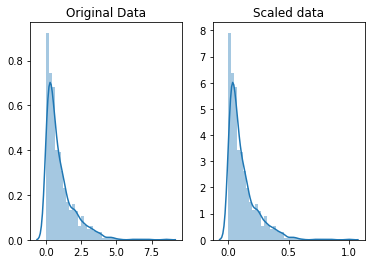

In [20]:
# generate 1000 data points randomly drawn from an exponential distribution
original_data = np.random.exponential(size = 1000)

# mix-max scale the data between 0 and 1
scaled_data = minmax_scaling(original_data, columns = [0])

# plot both together to compare
fig, ax=plt.subplots(1,2)
sns.distplot(original_data, ax=ax[0])
ax[0].set_title("Original Data")
sns.distplot(scaled_data, ax=ax[1])
ax[1].set_title("Scaled data")

Notice that the *shape* of the data doesn't change, but that instead of ranging from 0 to 8ish, it now ranges from 0 to 1.

___
## Normalization

Scaling just changes the range of your data. Normalization is a more radical transformation. The point of normalization is to change your observations so that they can be described as a normal distribution.

> **[Normal distribution:](https://en.wikipedia.org/wiki/Normal_distribution)** Also known as the "bell curve", this is a specific statistical distribution where a roughly equal observations fall above and below the mean, the mean and the median are the same, and there are more observations closer to the mean. The normal distribution is also known as the Gaussian distribution.

Normality assumptions apply to specific quantities, not necessarily to every raw variable. For example, classical linear regression assumes normally distributed errors for exact finite-sample inference, not normally distributed predictors; t-tests and ANOVAs concern group distributions or errors, while LDA and Gaussian naive Bayes make class-conditional distributional assumptions.

The method were  using to normalize here is called the [Box-Cox Transformation](https://en.wikipedia.org/wiki/Power_transform#Box%E2%80%93Cox_transformation). Let's take a quick peek at what normalizing some data looks like:

Text(0.5,1,'Normalized data')

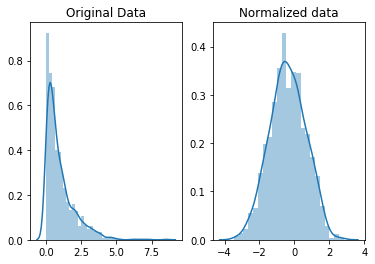

In [21]:
# normalize the exponential data with boxcox
normalized_data = stats.boxcox(original_data)

# plot both together to compare
fig, ax=plt.subplots(1,2)
sns.distplot(original_data, ax=ax[0])
ax[0].set_title("Original Data")
sns.distplot(normalized_data[0], ax=ax[1])
ax[1].set_title("Normalized data")

Notice that the *shape* of our data has changed. Before normalizing it was almost L-shaped. But after normalizing it looks more like the outline of a bell (hence "bell curve"). 

___
## Your turn!

For the following example, decide whether scaling or normalization makes more sense. 

* You want to build a linear regression model to predict someone's grades given how much time they spend on various activities during a normal school week.  You notice that your measurements for how much time students spend studying aren't normally distributed: some students spend almost no time studying and others study for four or more hours every day. Should you scale or normalize this variable?
* You're still working on your grades study, but you want to include information on how students perform on several fitness tests as well. You have information on how many jumping jacks and push-ups each student can complete in a minute. However, you notice that students perform far more jumping jacks than push-ups: the average for the former is 40, and for the latter only 10. Should you scale or normalize these variables?

**Réponse :** (« normaliser » est pris ici au sens du notebook : rapprocher la distribution d'une loi normale.)

- **Temps d'étude → normaliser si l'objectif est de réduire sa forte asymétrie.** La régression linéaire ne suppose pas que les variables explicatives soient normales ; la normalité porte sur les erreurs et ne sert qu'à l'inférence (tests, intervalles). Une variable très asymétrique peut toutefois s'accompagner de valeurs extrêmes en $x$, donc de points à fort levier. Elle ne rend pas, à elle seule, la relation avec la réponse non linéaire : cette relation doit être vérifiée séparément. Une transformation de Box-Cox peut rendre la distribution plus régulière :
$$y^{(\lambda)} = \begin{cases} \dfrac{y^{\lambda}-1}{\lambda} & \text{si } \lambda \neq 0 \\[4pt] \ln y & \text{si } \lambda = 0 \end{cases}$$
Box-Cox exige $y > 0$ : si certains élèves n'étudient pas du tout ($y = 0$), on utilise plutôt $\ln(1+y)$ ou la transformation de Yeo-Johnson.

- **Jumping jacks et pompes → mettre à l'échelle.** Le problème n'est pas la forme des distributions mais leurs échelles ; des moyennes de 40 et de 10 ne suffisent pas, à elles seules, à établir une différence d'échelle, et il faut aussi examiner la dispersion. On utilise par exemple la mise à l'échelle min-max $x' = \dfrac{x - \min x}{\max x - \min x} \in [0, 1]$ ou la standardisation $z = \dfrac{x - \bar{x}}{s}$.

En régression linéaire par moindres carrés **avec constante**, cela ne change pas les prédictions, mais rend les coefficients plus faciles à comparer. Avec une pénalisation (Ridge, Lasso) ou une méthode fondée sur des distances, une mise à l'échelle est généralement nécessaire pour éviter que l'unité arbitraire des variables ne domine le calcul.

# Practice scaling
___

To practice scaling and normalization, we're going to be using a dataset of Kickstarter campaigns. (Kickstarter is a website where people can ask people to invest in various projects and concept products.)

Let's start by scaling the goals of each campaign, which is how much money they were asking for.

Text(0.5,1,'Scaled data')

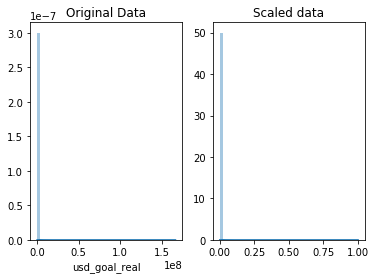

In [22]:
# select the usd_goal_real column
usd_goal = kickstarters_2017.usd_goal_real

# scale the goals from 0 to 1
scaled_data = minmax_scaling(usd_goal, columns = [0])

# plot the original & scaled data together to compare
fig, ax=plt.subplots(1,2)
sns.distplot(kickstarters_2017.usd_goal_real, ax=ax[0])
ax[0].set_title("Original Data")
sns.distplot(scaled_data, ax=ax[1])
ax[1].set_title("Scaled data")

You can see that scaling changed the scales of the plots dramatically (but not the shape of the data: it looks like most campaigns have small goals but a few have very large ones)

Plage d'origine : [0 ; 100000000]
Plage après mise à l'échelle : [0.0 ; 1.0]

Répartition des devises (%) :
USD    78.00
GBP     9.01
EUR     4.60
CAD     3.95
AUD     2.10
Name: currency, dtype: float64


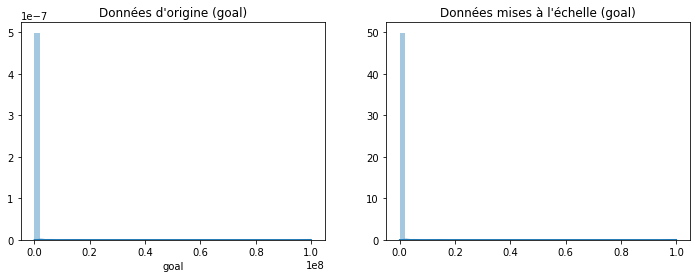

In [23]:
# Your turn! 

# We just scaled the "usd_goal_real" column. What about the "goal" column?
goal = kickstarters_2017.goal
# np.asarray(...).ravel() : sortie 1D quel que soit le type renvoyé par mlxtend
scaled_goal = np.asarray(minmax_scaling(goal, columns=[0])).ravel()

# Vérification : la mise à l'échelle min-max doit donner exactement [0, 1]
print(f"Plage d'origine : [{goal.min():.0f} ; {goal.max():.0f}]")
print(f"Plage après mise à l'échelle : [{scaled_goal.min():.1f} ; {scaled_goal.max():.1f}]")

# Contrairement à usd_goal_real, goal est exprimé dans la devise du projet
print("\nRépartition des devises (%) :")
print(kickstarters_2017.currency.value_counts(normalize=True).mul(100).round(2).head())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.distplot(goal, ax=ax[0])
ax[0].set_title("Données d'origine (goal)")
sns.distplot(scaled_goal, ax=ax[1])
ax[1].set_title("Données mises à l'échelle (goal)")
plt.show()

**Réponse :** après la mise à l'échelle min-max, `goal` va bien de 0 à 1, et la forme de la distribution est inchangée : presque toutes les campagnes ont un petit objectif, quelques-unes un objectif énorme (jusqu'à 100 000 000).

Deux limites apparaissent :
- **Sensibilité aux valeurs extrêmes.** Avec $x' = \dfrac{x - \min x}{\max x - \min x}$, un seul objectif de $10^8$ fixe le dénominateur : un objectif de 10 000 devient $x' \approx 10^{-4}$. Presque toutes les valeurs se retrouvent écrasées contre 0, d'où le pic unique du graphique. Une transformation logarithmique avant la mise à l'échelle, ou une mise à l'échelle robuste fondée sur la médiane et l'écart interquartile, serait plus adaptée.
- **Devises mélangées.** `goal` est exprimé dans la devise du projet : 78 % en USD, mais aussi 9,01 % en GBP, 4,60 % en EUR, 3,95 % en CAD, etc. Mettre cette colonne à l'échelle revient à comparer des livres sterling et des dollars, exactement le problème décrit au début du notebook avec les yens. Aucune mise à l'échelle ne corrige des unités mélangées : il faut d'abord convertir, ce que fait `usd_goal_real`.

# Practice normalization
___

Ok, now let's try practicing normalization. We're going to normalize the amount of money pledged to each campaign.

Text(0.5,1,'Normalized data')

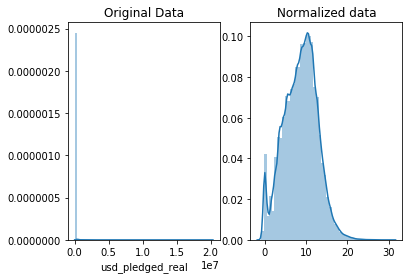

In [24]:
# get the index of all positive pledges (Box-Cox only takes postive values)
index_of_positive_pledges = kickstarters_2017.usd_pledged_real > 0

# get only positive pledges (using their indexes)
positive_pledges = kickstarters_2017.usd_pledged_real.loc[index_of_positive_pledges]

# normalize the pledges (w/ Box-Cox)
normalized_pledges = stats.boxcox(positive_pledges)[0]

# plot both together to compare
fig, ax=plt.subplots(1,2)
sns.distplot(positive_pledges, ax=ax[0])
ax[0].set_title("Original Data")
sns.distplot(normalized_pledges, ax=ax[1])
ax[1].set_title("Normalized data")

It's not perfect (it looks like a lot pledges got very few pledges) but it is much closer to normal!

Valeurs nulles exclues : 52527 sur 378661
λ estimé par Box-Cox : 0,0619
Asymétrie avant : 69,87 ; après : -0,01

Valeurs proches selon np.isclose, projets en USD : 100,00 %
Valeurs proches selon np.isclose, autres devises : 0,01 %
Corrélation de Spearman entre pledged et usd_pledged_real : 0,9951


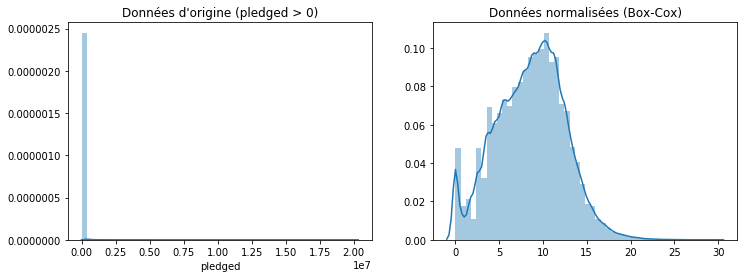

In [25]:
# Your turn! 
# We looked as the usd_pledged_real column. What about the "pledged" column? Does it have the same info?
pledged = kickstarters_2017.pledged
usd_pledged = kickstarters_2017.usd_pledged_real

# Box-Cox n'accepte que des valeurs strictement positives
is_positive = pledged > 0
positive_pledged = pledged.loc[is_positive]
normalized_pledged, lambda_pledged = stats.boxcox(positive_pledged)

print(f"Valeurs nulles exclues : {(~is_positive).sum()} sur {len(pledged)}")
print(f"λ estimé par Box-Cox : {lambda_pledged:.4f}".replace('.', ','))
print(f"Asymétrie avant : {stats.skew(positive_pledged):.2f} ; après : {stats.skew(normalized_pledged):.2f}".replace('.', ','))

# pledged contient-il la même information que usd_pledged_real ? (montants > 0 uniquement)
is_usd = (kickstarters_2017.currency == 'USD').values
same_value = np.isclose(pledged, usd_pledged) & is_positive.values

pct_usd = same_value[is_usd & is_positive.values].mean() * 100
pct_other = same_value[~is_usd & is_positive.values].mean() * 100

pct_usd_txt = f"{pct_usd:.2f}".replace('.', ',')
pct_other_txt = f"{pct_other:.2f}".replace('.', ',')

print(f"\nValeurs proches selon np.isclose, projets en USD : {pct_usd_txt} %")
print(f"Valeurs proches selon np.isclose, autres devises : {pct_other_txt} %")

rho = stats.spearmanr(pledged, usd_pledged).correlation
print(f"Corrélation de Spearman entre pledged et usd_pledged_real : {rho:.4f}".replace('.', ','))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.distplot(positive_pledged, ax=ax[0])
ax[0].set_title("Données d'origine (pledged > 0)")
sns.distplot(normalized_pledged, ax=ax[1])
ax[1].set_title("Données normalisées (Box-Cox)")
plt.show()

**Réponse :**

- **Normalisation.** Box-Cox estime $\hat{\lambda} \approx 0{,}062$. Cette valeur est proche de 0 : la transformation ressemble à un logarithme (cas $\lambda = 0$), en un peu moins concave. L'approximation par $\ln y$ n'est bonne que si $\lambda \ln y$ est petit : pour $y = 10\,000$, $\ln y \approx 9{,}2$ mais $y^{(0{,}062)} \approx 12{,}4$. L'asymétrie passe de **69,87 à −0,01** : la distribution obtenue est quasi symétrique.

- **Valeurs nulles.** Box-Cox exige $y > 0$, donc 52 527 campagnes sur 378 661 (13,87 %) ont été exclues, car elles n'ont reçu aucun don. Ce n'est pas anodin : ces campagnes forment un groupe à part, celui des échecs complets. Pour les conserver, on peut utiliser $\ln(1 + y)$ ou la transformation de Yeo-Johnson.

- **Même information que `usd_pledged_real` ?** Pas exactement. Parmi les campagnes ayant reçu au moins un don, les deux colonnes sont **numériquement proches au sens de `np.isclose`** pour 100 % des projets en USD, mais pour seulement 0,01 % des projets en autres devises : `pledged` est exprimé dans la devise du projet, `usd_pledged_real` est converti en dollars. Le classement des campagnes reste presque le même (corrélation de Spearman $\rho \approx 0{,}995$, calculée sur toutes les campagnes, y compris les quelque 52 500 paires $(0, 0)$, qui peuvent influencer le coefficient), mais les montants ne sont comparables entre projets qu'avec `usd_pledged_real`.

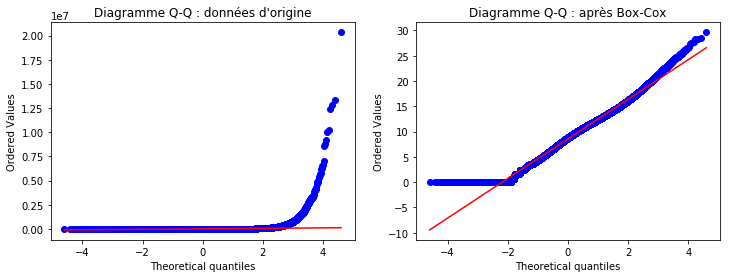

In [26]:
# Bonus : le diagramme Q-Q juge la normalité plus finement qu'un histogramme
# (points alignés sur la droite = quantiles conformes à une loi normale)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(positive_pledged, dist="norm", plot=ax[0])
ax[0].set_title("Diagramme Q-Q : données d'origine")
stats.probplot(normalized_pledged, dist="norm", plot=ax[1])
ax[1].set_title("Diagramme Q-Q : après Box-Cox")
plt.show()

**Lecture :**
- **Avant la transformation**, les points s'écartent fortement de la droite : la queue de distribution à droite est très lourde.
- **Après Box-Cox**, les points suivent la droite sur l'essentiel de la distribution. Des écarts subsistent aux extrémités ; on voit notamment un palier vers la valeur transformée 0, correspondant aux campagnes ayant reçu exactement 1 unité de devise, et la queue droite reste légèrement plus lourde que celle d'une loi normale.

La transformation rapproche donc fortement les données d'une loi normale, sans les rendre parfaitement gaussiennes.

Avec $n \approx 326\,000$, les tests de normalité ont une très forte puissance contre de petits écarts à la normalité. Un test de Kolmogorov-Smirnov standard exige en outre une loi de référence entièrement spécifiée ; si ses paramètres sont estimés sur les mêmes données, il faut adapter la calibration. Ici, le diagramme Q-Q est plus informatif sur l'importance pratique des écarts.

## Synthèse

| Étape | Constat | Choix et justification |
|---|---|---|
| Question conceptuelle | Temps d'étude asymétrique ; jumping jacks et pompes sur des échelles différentes | Réduire l'asymétrie du premier si nécessaire ; mettre à l'échelle les seconds |
| `goal` (min-max) | Plage ramenée à $[0, 1]$, forme inchangée ; un objectif de $10^8$ écrase toutes les autres valeurs | Préférer un logarithme ou une mise à l'échelle robuste ; utiliser `usd_goal_real`, car des devises mélangées exigent une conversion |
| `pledged` (Box-Cox) | $\hat{\lambda} \approx 0{,}062$, allure logarithmique ; asymétrie de 69,87 à −0,01 | Distribution quasi symétrique, mais 13,87 % de montants nuls exclus |
| `pledged` et `usd_pledged_real` | Parmi les montants non nuls : proches selon `np.isclose` pour 100 % des projets en USD, 0,01 % des autres ; $\rho \approx 0{,}995$ | Comparer les montants uniquement après conversion dans une même devise |
| Diagramme Q-Q | Points alignés sauf aux extrémités | Quasi normal, sans l'être parfaitement |

**À retenir :** des variables sur des échelles différentes se comparent après une mise à l'échelle ; des unités mélangées dans une même colonne exigent une conversion préalable ; un problème de forme peut être traité par une transformation non linéaire comme le logarithme ou Box-Cox.

And that's it for today! If you have any questions, be sure to post them in the comments below or [on the forums](https://www.kaggle.com/questions-and-answers). 

Remember that your notebook is private by default, and in order to share it with other people or ask for help with it, you'll need to make it public. First, you'll need to save a version of your notebook that shows your current work by hitting the "Commit & Run" button. (Your work is saved automatically, but versioning your work lets you go back and look at what it was like at the point you saved it. It also lets you share a nice compiled notebook instead of just the raw code.) Then, once your notebook is finished running, you can go to the Settings tab in the panel to the left (you may have to expand it by hitting the [<] button next to the "Commit & Run" button) and setting the "Visibility" dropdown to "Public".

# More practice!
___

Try finding a new dataset and pretend you're preparing to preform a [regression analysis](https://www.kaggle.com/rtatman/the-5-day-regression-challenge). ([These datasets are a good start!](https://www.kaggle.com/rtatman/datasets-for-regression-analysis)) Pick three or four variables and decide if you need to normalize or scale any of them and, if you think you should, practice applying the correct technique.